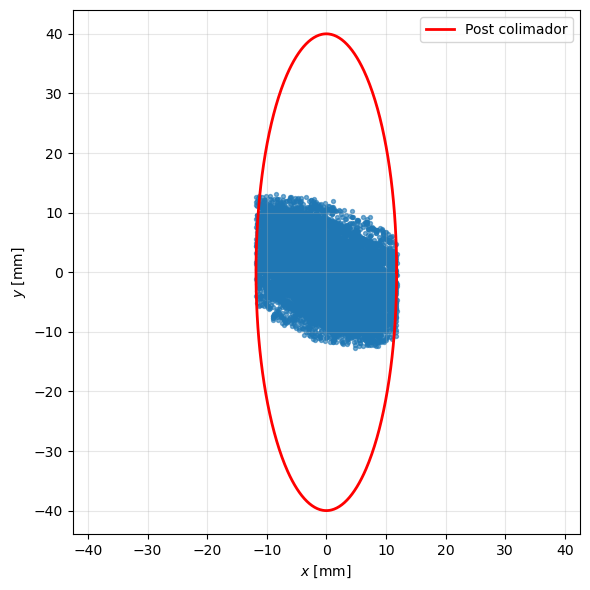

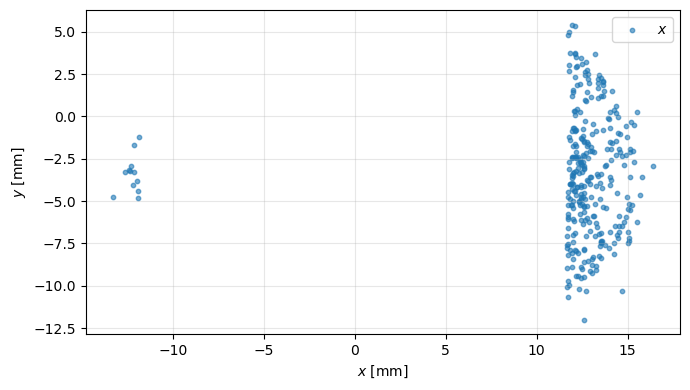

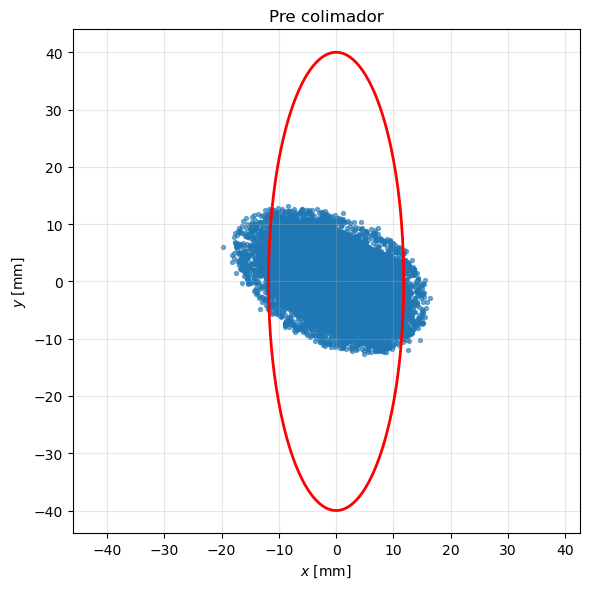

14857


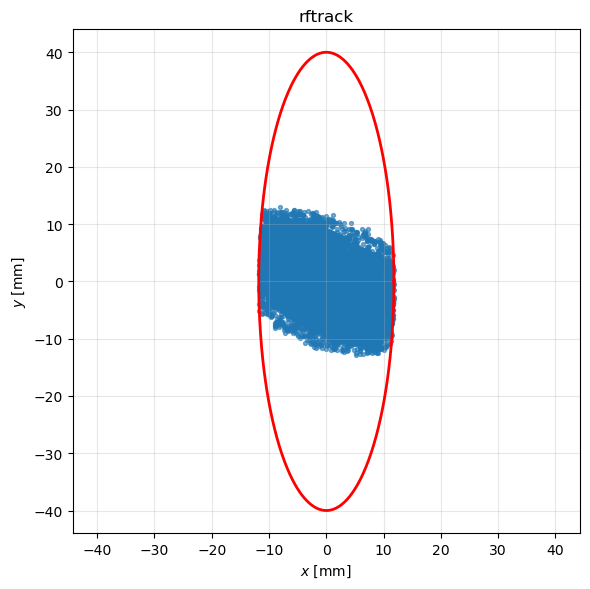

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


cols = ["x", "y", "z", "px", "py", "pz", "id", "time"]

def read_loss_file(file):
    file = Path(file)

    df = pd.read_csv(file, sep=r"\s+", comment="#", names=cols)


    df["id"] = df["id"].astype(int)
    df["x_mm"] = df["x"] * 1e3
    df["y_mm"] = df["y"] * 1e3
    df["z_mm"] = df["z"] * 1e3
    df["xp_mrad"] = df["px"] / df["pz"] * 1e3
    df["yp_mrad"] = df["py"] / df["pz"] * 1e3
    return df

loss = read_loss_file("COLLX.loss") 
opal_monitor=read_loss_file("MONITOR_TEST2.loss")
opal_post_monitor=read_loss_file("MONITOR_TEST1.loss")

xsize_mm = 0.0118 * 1e3
ysize_mm = 0.0400 * 1e3

t = np.linspace(0, 2*np.pi, 500)
x_ell = xsize_mm * np.cos(t)
y_ell = ysize_mm * np.sin(t)


plt.figure(figsize=(6, 6))
plt.scatter(opal_monitor["x_mm"], opal_monitor["y_mm"], s=8, alpha=0.6)
plt.plot(x_ell, y_ell, "r-", lw=2, label="Post colimador")

plt.xlabel(r"$x$ [mm]")
plt.ylabel(r"$y$ [mm]")
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))

plt.scatter(loss["x_mm"], loss["y_mm"], s=10, alpha=0.6, label=r"$x$")
plt.xlabel(r"$x$ [mm]")
plt.ylabel(r"$y$ [mm]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(opal_post_monitor["x_mm"], opal_post_monitor["y_mm"], s=8, alpha=0.6)
plt.plot(x_ell, y_ell, "r-", lw=2, label="Apertura COLLX")
plt.xlabel(r"$x$ [mm]")
plt.title("Pre colimador")
plt.ylabel(r"$y$ [mm]")
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.tight_layout()
plt.show()

phase_file = Path("..") / "rftrack" / "rftrack_lebt_phase space.txt"

phase_rf = pd.read_csv(
    phase_file,
    sep=r"\s+",
    comment="#",
    names=["x_mm", "y_mm"]
)

print(len(phase_rf["x_mm"]))
plt.figure(figsize=(6, 6))
plt.scatter(phase_rf["x_mm"], phase_rf["y_mm"], s=8, alpha=0.6)
plt.plot(x_ell, y_ell, "r-", lw=2, label="Apertura COLLX")
plt.xlabel(r"$x$ [mm]")
plt.title("rftrack")
plt.ylabel(r"$y$ [mm]")
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.tight_layout()
plt.show()

